In [ ]:
#Install the pack if you want to test
#!pip install tenacity==9.0.0
#!pip install langchain==0.3.12
#!pip install langchain-openai==0.2.12
#!pip install langchain_community==0.3.12
#!pip install langgraph==0.2.59
#!pip install pysqlite3-binary==0.5.4
#!pip install langchain_chroma==0.1.4
#!pip install pandas==2.2.3
#!pip install -U pypdf
#!pip install nbformat==5.10.4
#!pip install pysqlite3
#!pip install "posthog>=2.4.0,<6.0.0" #Fix chroma error
#!pip install fuzzywuzzy #in case a typo
#!pip install python-Levenshtein #for fuzzywuzzy packg

  Attempting uninstall: tenacity
    Found existing installation: tenacity 9.1.4
    Uninstalling tenacity-9.1.4:
      Successfully uninstalled tenacity-9.1.4
INFO: pip is looking at multiple versions of langchain-core to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of langchain-core to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.5/438.5 kB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 326.9/326.9 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.6/948.6 kB 48.1 MB/s eta 0:00:00
  Attempting uninstall: openai
    Found existing installation: openai 2.28.0
    Uninstalling openai-2.28.0:
      Successfully uninstalled openai-2.28.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 77.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.3/50.3 kB 4.7 MB/s eta 0:00:00
  Attempting uninstall: langgraph-sdk
    Found existing installation: langgraph-sdk 0.3.11
    Uninstalling langgraph-sdk-0.3.11:
      Successfully uninstalled langgraph-sdk-0.3.11
  Attempting uninstall: langgraph-checkpoint
    Found existing installation: langgraph-checkpoint 4.0.1
    Uni

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 103.9 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.2.3 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
tobler 0.13.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.7/333.7 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 80.5 MB/s eta 0:00:00
   ━━━

In [ ]:
from langchain_openai import ChatOpenAI
from google.colab import userdata
import os

#Mount GoogleDrive for data
from google.colab import drive
drive.mount('/content/drive')

# API info. Replace with your own keys
os.environ["OPENAI_API_KEY"] = userdata.get("OpenAiAPI")

# Setup the LLM
model = ChatOpenAI(
    model="gpt-5.1",
    temperature=0.7
)


Mounted at /content/drive


## Setup tools for custom Agent

In [ ]:
import pandas as pd

#Load the laptop product orders CSV into a Pandas dataframe.
product_orders_df = pd.read_csv("/content/drive/MyDrive/Group 3 - Agentic AI in Customer Service and Sales/data/pc_parts_orders.csv")
print(product_orders_df)

  OrderID                          Name  Quantity Ordered  ShippingDays
0  JP908U   Storage - 1TB NVMe SSD Gen4                 2             2
1  CKMR21   GPU - NVIDIA RTX 4070 Super                 1             5
2  2MBX7G  Motherboard - ASUS B650-PLUS                 2             4
3  DBPXMU    Monitor - 27in 1440p 165Hz                 3             5
4  P15YWY  Motherboard - ASUS B650-PLUS                 1             4
5  9V81KQ    Monitor - 27in 1440p 165Hz                 2             5
6  MGR14S    Monitor - 27in 1440p 165Hz                 1             5
7  5OA17Z   Storage - 1TB NVMe SSD Gen4                 4             2
8  2F1WRY   Storage - 1TB NVMe SSD Gen4                 2             2
9  PUCZFF       RAM - 32GB DDR5 6000MHz                12             2


In [ ]:
from langchain_core.tools import tool

@tool
def get_order_details(order_id:str) -> str :
    """
    This function returns details about a pc parts order, given an order ID
    It performs an exact match between the input order id and available order ids
    If a match is found, it returns products (pc part) ordered, quantity ordered and delivery date.
    If there is NO match found, it returns -1
    """
    #Filter Dataframe for order ID
    match_order_df = product_orders_df[
                        product_orders_df["OrderID"] == order_id ]

    #Check if a record was found, if not return -1
    if len(match_order_df) == 0 :
        return -1
    else:
        return match_order_df.iloc[0].to_dict()

#Test the tool. Before running the test, comment the @tool annotation
#print(get_order_details("5OA17Z"))
#print(get_order_details("PUCZFF"))

@tool
def update_quantity(order_id:str, new_quantity:int) -> bool :
    """
    This function updates the quantity of products ( pc part ) ordered for a given order Id.
    It there are no matching orders, it returns -1.
    """
    #Find if matching record exists
    match_order_df = product_orders_df[
                        product_orders_df["OrderID"] == order_id ]

    #Check if a record was found, if not return -1
    if len(match_order_df) == 0 :
        return -1
    else:
        product_orders_df.loc[
            product_orders_df["OrderID"] == order_id,
                "Quantity Ordered"] = new_quantity
        return True

#Test the tool. Before running the test, comment the @tool annotation
#print(get_order_details("CKMR21"))
#print(update_quantity("CKMR21", 1))
#print(get_order_details("MGR14S"))
#print(update_quantity("MGR14S",2))
#print(product_orders_df)

##Setup the Custom Orders Agent

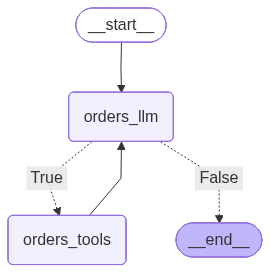

In [ ]:
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver
from typing import TypedDict, Annotated
import operator
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, ToolMessage
from IPython.display import Image
import json

#An Agent State class that keep state of the agent while it answers a query
class OrdersAgentState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]

#-----------------------------------------------------------------------------
#An agent class that manages all agentic interactions
class OrdersAgent:

    #Setup the agent graph, tools and memory
    def __init__(self, model, tools, system_prompt, debug):

        self.system_prompt=system_prompt
        self.debug=debug

        #Setup the graph for the agent manually
        agent_graph=StateGraph(OrdersAgentState)
        agent_graph.add_node("orders_llm",self.call_llm)
        agent_graph.add_node("orders_tools",self.call_tools)
        agent_graph.add_conditional_edges(
            "orders_llm",
            self.is_tool_call,
            {True: "orders_tools", False: END }
        )
        agent_graph.add_edge("orders_tools","orders_llm")
        #Set where there graph starts
        agent_graph.set_entry_point("orders_llm")

        #Add chat memory
        self.memory=MemorySaver()
        #compile the graph
        self.agent_graph = agent_graph.compile(checkpointer=self.memory)

        #Setup tools
        self.tools = { tool.name : tool for tool in tools }
        if self.debug:
            print("\nTools loaded :", self.tools)

        #attach tools to model
        self.model=model.bind_tools(tools)


    #Call the LLM with the messages to get next action/result
    def call_llm(self, state:OrdersAgentState):

        messages=state["messages"]

        #If system prompt exists, add to messages in the front
        if self.system_prompt:
            messages = [SystemMessage(content=self.system_prompt)] + messages

        #invoke the model with the message history
        result = self.model.invoke(messages)
        if self.debug:
            print(f"\nLLM Returned : {result}")
        #Return the LLM output
        return { "messages":[result] }


    #Check if the next action is a tool call.
    def is_tool_call(self, state:OrdersAgentState):
        last_message = state["messages"][-1]
        #print("Last result from LLM : ", last_message)
        #If tool action is requested
        if len(last_message.tool_calls) > 0 :
            return True
        else:
            return False

    #Execute the tool requested with the given parameters
    def call_tools(self, state:OrdersAgentState):
        #Get last message
        tool_calls = state["messages"][-1].tool_calls
        results=[]

        #Multiple tool calls may be requested. Execute one by one
        for tool in tool_calls:
            #Handle tool missing error
            if not tool["name"] in self.tools:
                print(f"Unknown tool name {tool}")
                result = "Invalid tool found. Please retry"
            else:
                #Call the tool and collect results
                result=self.tools[tool["name"]].invoke(tool["args"])

            #append results to the list of tool results
            results.append(ToolMessage(tool_call_id=tool['id'],
                                       name=tool['name'],
                                       content=str(result)))

            if self.debug:
                print(f"\nTools returned {results}")
            #return tool results
            return { "messages" : results }

#-----------------------------------------------------------------------------
#Setup the custom agent

#Note that this is a string, since the model init only accepts a string.
system_prompt = """
    You are professional chatbot that manages orders for computer and computer part sold by our company.
    The tools allow for retrieving order details as well as update order quantity.
    Do NOT reveal information about other orders than the one requested.
    You will handle small talk and greetings by producing professional responses.
    """

#Create the custom orders agent
orders_agent = OrdersAgent(model,
                           [get_order_details, update_quantity],
                           system_prompt,
                           debug=False)

#Visualize the Agent
Image(orders_agent.agent_graph.get_graph().draw_mermaid_png())


## This used to set and test the chat bot

In [ ]:
import uuid
#Send a sequence of messages to chatbot and get its response
#This simulates the conversation between the user and the Agentic chatbot
user_inputs = [
    "How are you doing?",
    "Please show me the details of the order CKMR21",
    "Can you add one more of that part to the order? ",
    "Can you show me the details again ? ",
    "What about order MGR14S ?",
    "Bye"
]

#Create a new thread
config = {"configurable": {"thread_id": str(uuid.uuid4())}}

for input in user_inputs:
    print(f"----------------------------------------\nUSER : {input}")
    #Format the user message
    user_message = {"messages":[HumanMessage(input)]}
    #Get response from the agent
    ai_response = orders_agent.agent_graph.invoke(user_message,config=config)
    #Print the response
    print(f"\nAGENT : {ai_response['messages'][-1].content}")

----------------------------------------
USER : How are you doing?

AGENT : I'm here and ready to assist you with your orders. How can I help you today?
----------------------------------------
USER : Please show me the details of the order CKMR21

AGENT : Here are the details for your order CKMR21:

- **Product Name**: GPU - NVIDIA RTX 4070 Super
- **Quantity Ordered**: 1
- **Estimated Delivery**: In 5 days

If you need any further assistance, feel free to ask!
----------------------------------------
USER : Can you add one more of that part to the order? 

AGENT : The quantity for your order CKMR21 has been successfully updated to 2 units of the GPU - NVIDIA RTX 4070 Super. If there's anything else I can assist you with, please let me know!
----------------------------------------
USER : Can you show me the details again ? 

AGENT : Here are the updated details for your order CKMR21:

- **Product Name**: GPU - NVIDIA RTX 4070 Super
- **Quantity Ordered**: 2
- **Estimated Delivery**: 